<a href="https://colab.research.google.com/github/falexanderforero/Deep-Learning---Fundamentos/blob/main/week10/%E2%80%93_Actividad_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Reduce tamaño (rápido)
x_train = x_train[:8000]
y_train = y_train[:8000]
x_test = x_test[:1000]
y_test = y_test[:1000]

# Normalización
x_train = x_train / 255.0
x_test = x_test / 255.0

# Agregar canal
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
def create_pairs(x, y):
    pairs = []
    labels = []

    num_classes = 10
    digit_indices = [np.where(y == i)[0] for i in range(num_classes)]

    for idx in range(len(x)):
        current_image = x[idx]
        label = y[idx]

        # PAR POSITIVO (misma clase)
        pos_idx = np.random.choice(digit_indices[label])
        pairs.append([current_image, x[pos_idx]])
        labels.append(1)

        # PAR NEGATIVO (distinta clase)
        neg_label = (label + np.random.randint(1, num_classes)) % num_classes
        neg_idx = np.random.choice(digit_indices[neg_label])
        pairs.append([current_image, x[neg_idx]])
        labels.append(0)

    return np.array(pairs), np.array(labels)

pairs_train, labels_train = create_pairs(x_train, y_train)
pairs_test, labels_test = create_pairs(x_test, y_test)

print("Pares creados:", pairs_train.shape)

Pares creados: (16000, 2, 28, 28, 1)


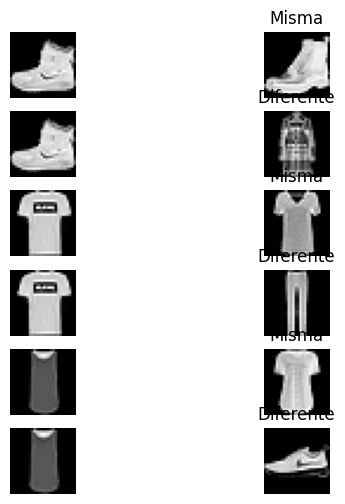

In [4]:
plt.figure(figsize=(6,6))
for i in range(6):
    plt.subplot(6,2,2*i+1)
    plt.imshow(pairs_train[i][0].squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(6,2,2*i+2)
    plt.imshow(pairs_train[i][1].squeeze(), cmap='gray')
    plt.title("Misma" if labels_train[i] == 1 else "Diferente")
    plt.axis('off')

plt.show()

In [5]:
def create_base_network():
    input = layers.Input(shape=(28,28,1))

    x = layers.Conv2D(32, (3,3), activation='relu')(input)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, (3,3), activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)

    return Model(input, x)

In [6]:
def l1_distance(vects):
    x, y = vects
    return tf.abs(x - y)

In [7]:
base_network = create_base_network()

input_a = layers.Input(shape=(28,28,1))
input_b = layers.Input(shape=(28,28,1))

# Ambas imágenes pasan por la MISMA red
processed_a = base_network(input_a)
processed_b = base_network(input_b)

# Comparación
distance = layers.Lambda(l1_distance)([processed_a, processed_b])

# Clasificación final
output = layers.Dense(1, activation='sigmoid')(distance)

siamese_model = Model([input_a, input_b], output)

siamese_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

siamese_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 64)        │    514,496 │ input_layer_1[0]… │
│ (Functional)        │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ functional[0][0], │
│                     │                   │            │ functional[1][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ lambda[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 514,561 (1.96 MB)

 Trainable params: 514,561 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = siamese_model.fit(
    [pairs_train[:,0], pairs_train[:,1]],
    labels_train,
    validation_data=([pairs_test[:,0], pairs_test[:,1]], labels_test),
    epochs=3,
    batch_size=32
)

Epoch 1/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 33s 62ms/step - accuracy: 0.8203 - loss: 0.3995 - val_accuracy: 0.8480 - val_loss: 0.3453
Epoch 2/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.8821 - loss: 0.2879 - val_accuracy: 0.8685 - val_loss: 0.3223
Epoch 3/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.9041 - loss: 0.2393 - val_accuracy: 0.8785 - val_loss: 0.3152


In [9]:
loss, acc = siamese_model.evaluate(
    [pairs_test[:,0], pairs_test[:,1]],
    labels_test
)

print(f"Accuracy: {acc:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8785 - loss: 0.3152
Accuracy: 0.8785


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


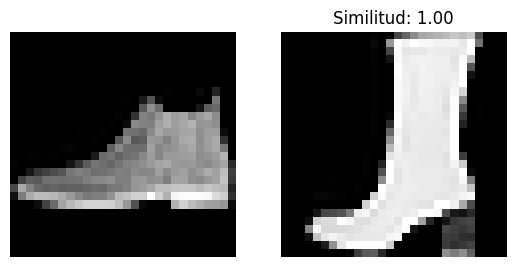

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


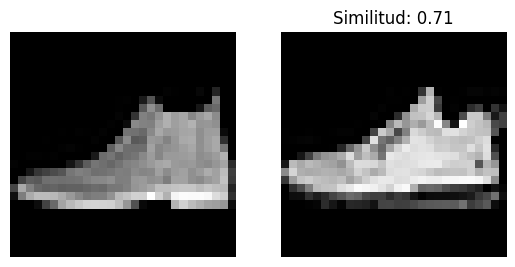

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


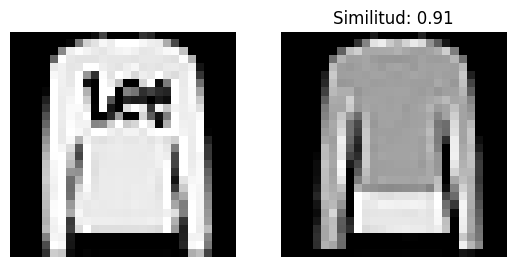

In [10]:
def test_pair(idx):
    img1 = pairs_test[idx][0]
    img2 = pairs_test[idx][1]

    pred = siamese_model.predict([img1[np.newaxis], img2[np.newaxis]])

    plt.subplot(1,2,1)
    plt.imshow(img1.squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img2.squeeze(), cmap='gray')
    plt.title(f"Similitud: {pred[0][0]:.2f}")
    plt.axis('off')

    plt.show()

# Probar algunos
for i in range(3):
    test_pair(i)

## ¿Qué es una red siamesa?

Es una arquitectura que compara dos entradas usando la misma red neuronal para extraer características y luego mide su similidad mediante una distancia.

## ¿Cómo funciona?
Dos imágenes entran al modelo
Ambas pasan por la misma red (pesos compartidos)
Se obtiene un vector (embedding)
Se calcula una distancia (L1 en este caso)
Se decide si son similares o diferentes
## Análisis
Pares positivos → el modelo aprende a reducir la distancia
Pares negativos → el modelo aprende a aumentarla
El accuracy indica qué tan bien distingue entre “misma clase” y “diferente clase”

## Conclusiones
Las redes siamesas son útiles cuando no se quiere clasificar directamente sino comparar
Son muy usadas en:
- reconocimiento facial
- verificación de identidad
- búsqueda de imágenes similares
- Funcionan bien incluso con pocos datos porque aprenden relaciones